In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import time
from tqdm import tqdm

In [46]:
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform_train
)

test_dataset = datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform_test
)

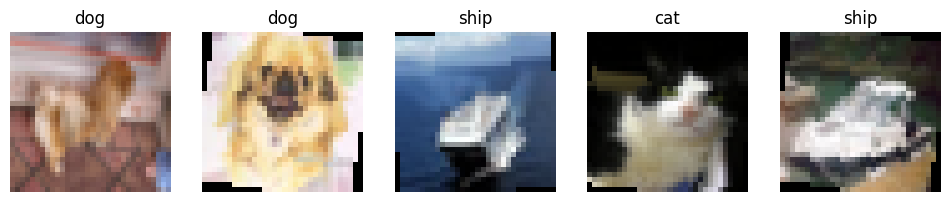

In [47]:
BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, shuffle=True, batch_size=BATCH_SIZE, drop_last=True)
test_loader = DataLoader(test_dataset, shuffle=False, batch_size=BATCH_SIZE, drop_last=True)

dataiter = iter(train_loader)
images, labels = next(dataiter)

classes = train_dataset.classes
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i in range(5):
    ax = axes[i]
    img = images[i] / 2 + 0.5
    ax.imshow(np.transpose(img, (1, 2, 0)))
    ax.set_title(classes[labels[i]])
    ax.axis('off')
plt.show()

In [48]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3,padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),

            nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),

            nn.MaxPool2d(2,2)
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.MaxPool2d(2,2)
        )

        self.block3 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.MaxPool2d(2,2)
        )

        self.fc_block = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(64 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10)
        )
    
    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        
        x = x.view(-1, 64 * 4 * 4)
        x = self.fc_block(x)

        return x


In [49]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
model = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=30,
    eta_min=1e-6
)

cuda


In [56]:
from torchinfo import summary
summary(model, input_size=(BATCH_SIZE, 3, 32, 32))

Layer (type:depth-idx)                   Output Shape              Param #
CNN                                      [64, 10]                  --
├─Sequential: 1-1                        [64, 16, 16, 16]          --
│    └─Conv2d: 2-1                       [64, 16, 32, 32]          448
│    └─BatchNorm2d: 2-2                  [64, 16, 32, 32]          32
│    └─ReLU: 2-3                         [64, 16, 32, 32]          --
│    └─Conv2d: 2-4                       [64, 16, 32, 32]          2,320
│    └─BatchNorm2d: 2-5                  [64, 16, 32, 32]          32
│    └─ReLU: 2-6                         [64, 16, 32, 32]          --
│    └─MaxPool2d: 2-7                    [64, 16, 16, 16]          --
├─Sequential: 1-2                        [64, 32, 8, 8]            --
│    └─Conv2d: 2-8                       [64, 32, 16, 16]          4,640
│    └─BatchNorm2d: 2-9                  [64, 32, 16, 16]          64
│    └─ReLU: 2-10                        [64, 32, 16, 16]          --
│    └─C

In [ ]:
history = {
    'train_loss': [], 'train_acc': [],
    'test_loss': [], 'test_acc': [],
    'lr': [], 'epoch_time': []
}

NUM_EPOCHS = 30
best_test_acc = 0.0

for epoch in range(NUM_EPOCHS):
    epoch_start = time.time()

    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    
    train_bar = tqdm(train_loader, desc=f'Эпоха {epoch+1}/{NUM_EPOCHS} [Train]')
    
    for inputs, labels in train_bar:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()

    epoch_train_loss = train_loss / len(train_loader)
    epoch_train_acc = 100. * train_correct / train_total

    model.eval()
    test_loss = 0.0
    test_correct = 0
    test_total = 0
    
    with torch.no_grad():
        test_bar = tqdm(test_loader, desc=f'Эпоха {epoch+1}/{NUM_EPOCHS} [Test]')
        
        for inputs, labels in test_bar:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            test_loss += loss.item()
            _, predicted = outputs.max(1)
            test_total += labels.size(0)
            test_correct += predicted.eq(labels).sum().item()
            
            
    
    epoch_test_loss = test_loss / len(test_loader)
    epoch_test_acc = 100. * test_correct / test_total
    

    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step()
    
    
    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['test_loss'].append(epoch_test_loss)
    history['test_acc'].append(epoch_test_acc)
    history['lr'].append(current_lr)
    history['epoch_time'].append(time.time() - epoch_start)
    

    print(f"{'='*60}")
    print(f"Эпоха [{epoch+1:02d}/{NUM_EPOCHS:02d}] | "
          f"Время: {history['epoch_time'][-1]:.1f}с | ")
    print(f"  Train | Loss: {epoch_train_loss:.4f} | Acc: {epoch_train_acc:6.2f}%")
    print(f"  Test  | Loss: {epoch_test_loss:.4f} | Acc: {epoch_test_acc:6.2f}%")
    if epoch_test_acc > best_test_acc:
        best_test_acc = epoch_test_acc
    print('='*60)

print(f"\n{'='*60}")
print(f"Лучшая точность на тесте: {best_test_acc:.2f}%")




Эпоха 1/30 [Test]: 100%|██████████| 156/156 [00:02<00:00, 68.35it/s]


Эпоха [01/30] | Время: 23.7с | 
  Train | Loss: 1.6038 | Acc:  40.70%
  Test  | Loss: 1.2618 | Acc:  54.10%


Эпоха 2/30 [Test]: 100%|██████████| 156/156 [00:02<00:00, 65.36it/s]


Эпоха [02/30] | Время: 21.5с | 
  Train | Loss: 1.2462 | Acc:  54.92%
  Test  | Loss: 0.9909 | Acc:  64.72%


Эпоха 3/30 [Test]: 100%|██████████| 156/156 [00:02<00:00, 69.52it/s]


...

Эпоха [28/30] | Время: 20.7с | 
  Train | Loss: 0.4945 | Acc:  82.74%
  Test  | Loss: 0.4623 | Acc:  84.44%


Эпоха 29/30 [Test]: 100%|██████████| 156/156 [00:02<00:00, 71.02it/s]


Эпоха [29/30] | Время: 20.5с | 
  Train | Loss: 0.4923 | Acc:  82.93%
  Test  | Loss: 0.4616 | Acc:  84.41%


Эпоха 30/30 [Test]: 100%|██████████| 156/156 [00:02<00:00, 71.42it/s]

Эпоха [30/30] | Время: 20.5с | 
  Train | Loss: 0.4897 | Acc:  83.20%
  Test  | Loss: 0.4622 | Acc:  84.32%

ОБУЧЕНИЕ ЗАВЕРШЕНО!
Лучшая точность на тесте: 84.44%


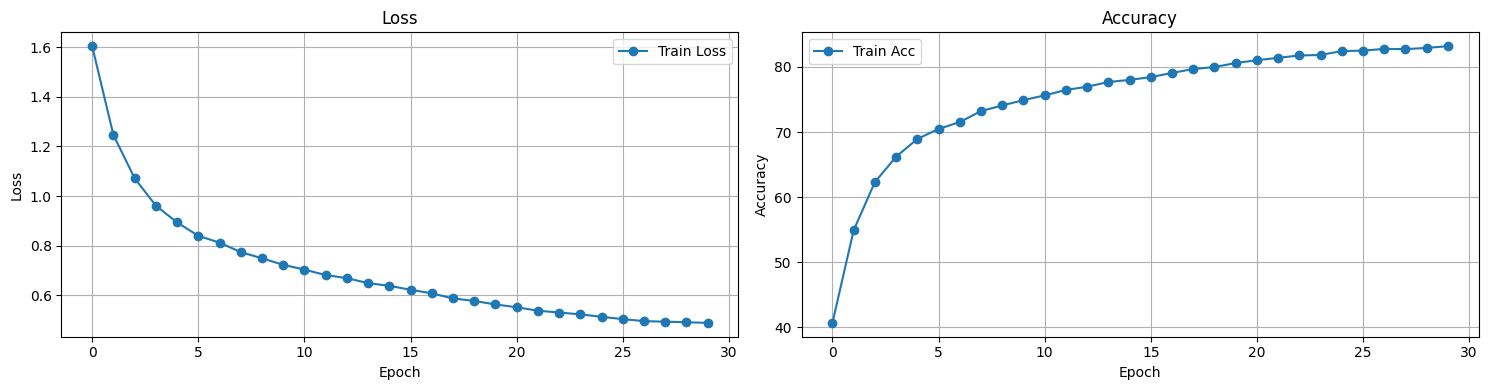

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history['train_acc'], label='Train Acc', marker='o')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()